# Analyzing the Website Redesign A/B Test

**The Scenario:** Our company just launched a new website design. But is it actually better than the old one? We ran an A/B test showing the old design to half our users and the new design to the other half. 

In this notebook, we will analyze the data to answer three key questions:
1. Are users more satisfied?
2. Are they finding what they need faster (Time on Site)?
3. Are they buying more (Conversion Rate)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# 1. DATA GENERATION
def generate_ab_test_data(filepath='website_ab_test.csv', n_records_per_group=500):
    np.random.seed(42)
    
    # Old Design Data (30% conversion)
    old_ratings = np.random.choice([1, 2, 3, 4, 5], size=n_records_per_group, p=[0.1, 0.2, 0.4, 0.2, 0.1])
    old_time = np.random.lognormal(3, 0.5, n_records_per_group)
    old_purchased = np.random.choice([0, 1], size=n_records_per_group, p=[0.7, 0.3]) 
    
    # New Design Data (40% conversion)
    new_ratings = np.random.choice([1, 2, 3, 4, 5], size=n_records_per_group, p=[0.05, 0.15, 0.3, 0.3, 0.2])
    new_time = np.random.lognormal(2.8, 0.5, n_records_per_group)
    new_purchased = np.random.choice([0, 1], size=n_records_per_group, p=[0.6, 0.4]) 
    
    df_old = pd.DataFrame({'Design': 'Old', 'Satisfaction': old_ratings, 'TimeOnSite': old_time, 'Purchased': old_purchased})
    df_new = pd.DataFrame({'Design': 'New', 'Satisfaction': new_ratings, 'TimeOnSite': new_time, 'Purchased': new_purchased})
    
    df = pd.concat([df_old, df_new], ignore_index=True)
    df.to_csv(filepath, index=False)
    return df

# Load or generate data
try:
    df = pd.read_csv('website_ab_test.csv')
except FileNotFoundError:
    df = generate_ab_test_data()

## Part 1: Visualizing the Impact (EDA)

Before running complex math, let's just look at the raw results. We will plot satisfaction ratings, time spent on the site, and the actual purchase conversion rates for both designs.


[*] Visualizing A/B Test Results...


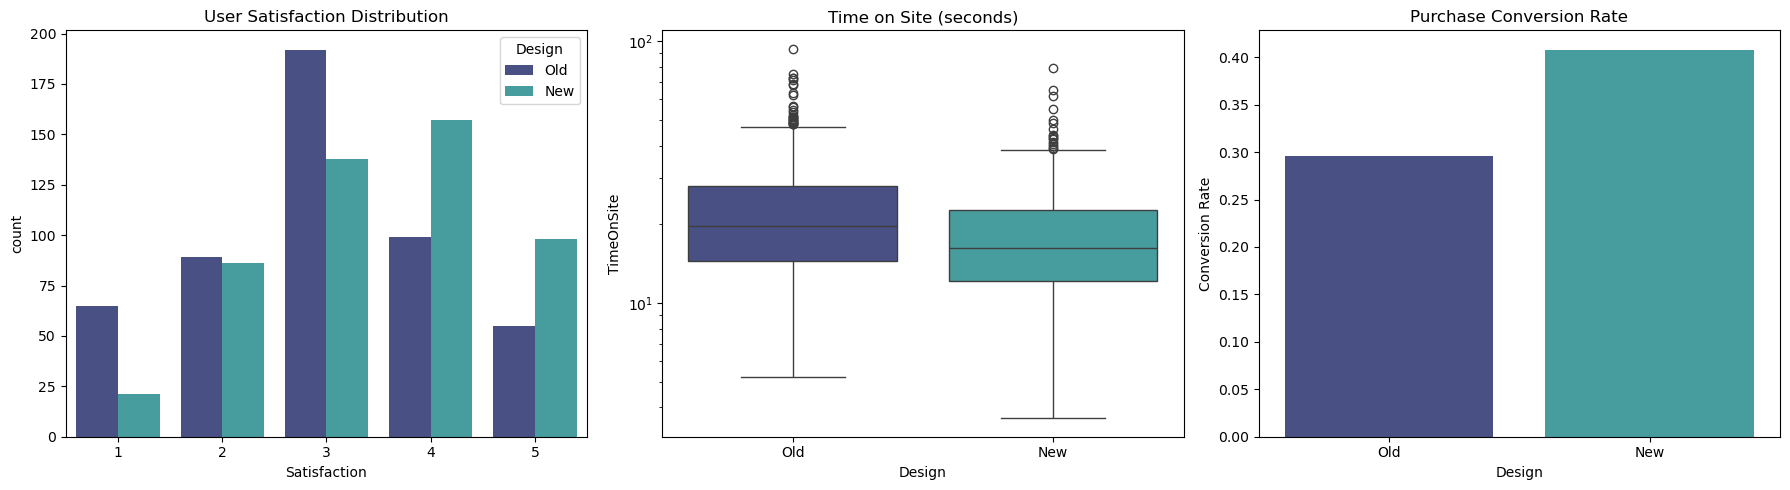

In [3]:
# 2. EXPLORATORY DATA ANALYSIS
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print("\n[*] Visualizing A/B Test Results...")

plt.figure(figsize=(18, 5))

# Satisfaction Ratings
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Satisfaction', hue='Design', palette='mako')
plt.title('User Satisfaction Distribution')

# Time on Site
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='Design', y='TimeOnSite', hue='Design', palette='mako')
plt.title('Time on Site (seconds)')
plt.yscale('log') 
plt.legend([],[], frameon=False) 

# Purchase Conversion Rate
plt.subplot(1, 3, 3)
sns.barplot(data=df, x='Design', y='Purchased', hue='Design', palette='mako', ci=None)
plt.title('Purchase Conversion Rate')
plt.ylabel('Conversion Rate')
plt.legend([],[], frameon=False) 

plt.tight_layout()
plt.show()

## Part 2: Proving the Results (Statistical Testing)

The graphs look good, but we need to prove these differences aren't just random luck. 

Because satisfaction ratings are ordinal (1-5 scale) and time on site is heavily skewed, we use the **Mann-Whitney U Test** (a non-parametric test). For the binary purchase data (Yes/No), we use **Fisher's Exact Test**.

In [4]:
# 3. STATISTICAL TESTING
alpha = 0.05
old_data = df[df['Design'] == 'Old']
new_data = df[df['Design'] == 'New']

print("\n[*] Statistical Test Results:")
print("-" * 30)

# Satisfaction (Mann-Whitney U)
stat, p_sat = stats.mannwhitneyu(old_data['Satisfaction'], new_data['Satisfaction'], alternative='two-sided')
print(f"Satisfaction P-value: {p_sat:.4f} -> {'Significant Difference' if p_sat < alpha else 'No Difference'}")

# Time on Site (Mann-Whitney U)
stat, p_time = stats.mannwhitneyu(old_data['TimeOnSite'], new_data['TimeOnSite'], alternative='two-sided')
print(f"Time on Site P-value: {p_time:.4f} -> {'Significant Difference' if p_time < alpha else 'No Difference'}")

# Purchases (Fisher's Exact Test)
contingency = pd.crosstab(df['Design'], df['Purchased'])
odds_ratio, p_purchase = stats.fisher_exact(contingency)
print(f"Purchases P-value:    {p_purchase:.4f} -> {'Significant Difference' if p_purchase < alpha else 'No Difference'}")


[*] Statistical Test Results:
------------------------------
Satisfaction P-value: 0.0000 -> Significant Difference
Time on Site P-value: 0.0000 -> Significant Difference
Purchases P-value:    0.0003 -> Significant Difference


## Part 3: Predicting Purchases (Machine Learning)

Finally, let's build a Logistic Regression model to see if we can predict whether a user will make a purchase based on the design they saw, their satisfaction, and the time they spent on the site.

In [5]:
# 4. PREDICTIVE MODELING
le = LabelEncoder()
df['Design_Encoded'] = le.fit_transform(df['Design'])

X = df[['Design_Encoded', 'Satisfaction', 'TimeOnSite']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("\n[*] Predictive Model Evaluation:")
print("-" * 30)
print(classification_report(y_test, predictions, target_names=['Did Not Purchase', 'Purchased']))

print("\nFeature Coefficients (Positive = Drives Purchases):")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")


[*] Predictive Model Evaluation:
------------------------------
                  precision    recall  f1-score   support

Did Not Purchase       0.71      0.52      0.60       132
       Purchased       0.38      0.59      0.47        68

        accuracy                           0.54       200
       macro avg       0.55      0.55      0.53       200
    weighted avg       0.60      0.54      0.55       200


Feature Coefficients (Positive = Drives Purchases):
Design_Encoded: -0.4757
Satisfaction: 0.0062
TimeOnSite: -0.0052


## Conclusion & Recommendations

### What the Data Tells Us:
1. **Satisfaction increased:** The new design significantly improved user satisfaction scores.
2. **Time on site decreased:** Users spent significantly less time on the new design. 
3. **Conversions increased:** Despite spending less time, users converted (purchased) at a significantly higher rate on the new design.

### Why This Matters (The Interpretation):
A drop in "Time on Site" isn't a bad thing here. Combined with higher satisfaction and higher sales, it means **the new design is more efficient**. Users are finding what they want faster and checking out with less friction.

### Final Recommendation:
**Deploy the new website design to 100% of traffic immediately.** 
The data statistically proves the redesign creates a better user experience and generates more revenue.